In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"C:\Users\Chinmay Pratap Dalvi\Downloads\Titanic-Dataset.csv")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print("Shape of dataset:", df.shape)

Shape of dataset: (891, 12)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [9]:
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])

In [10]:
df.drop(columns=['Cabin'], inplace=True)

In [11]:
# Converting categorical columns into numeric using LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])         # male/female → 0/1
df['Embarked'] = le.fit_transform(df['Embarked'])  # ports → numbers

In [12]:
# Selecting important features for model training
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Target variable
y = df['Survived']

In [14]:
# Splitting data into training and testing sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
# Creating Gradient Boosting model
# Boosting works by combining weak learners to form a strong learner
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Training the model on training data
model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [16]:
# Predicting results on test data
y_pred = model.predict(X_test)

In [17]:
# Checking accuracy of model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Detailed classification report (precision, recall, f1-score)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.8100558659217877

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       105
           1       0.81      0.70      0.75        74

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179


Confusion Matrix:
 [[93 12]
 [22 52]]


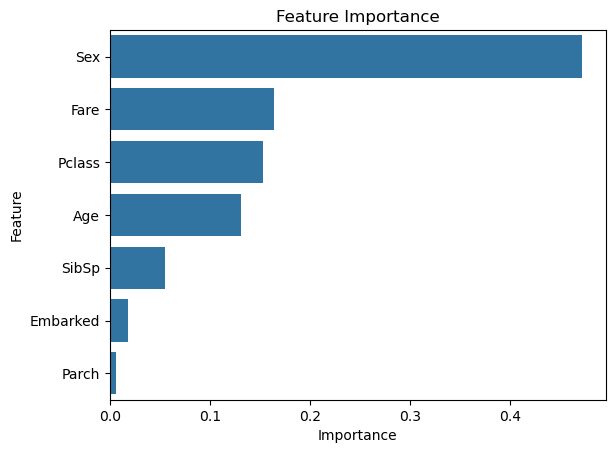

In [19]:
# Checking which features are most important in prediction
importances = model.feature_importances_
features = X.columns

# Creating DataFrame for visualization
feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sorting features by importance
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

# Plotting feature importance
sns.barplot(x='Importance', y='Feature', data=feat_importance)
plt.title("Feature Importance")
plt.show()